In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


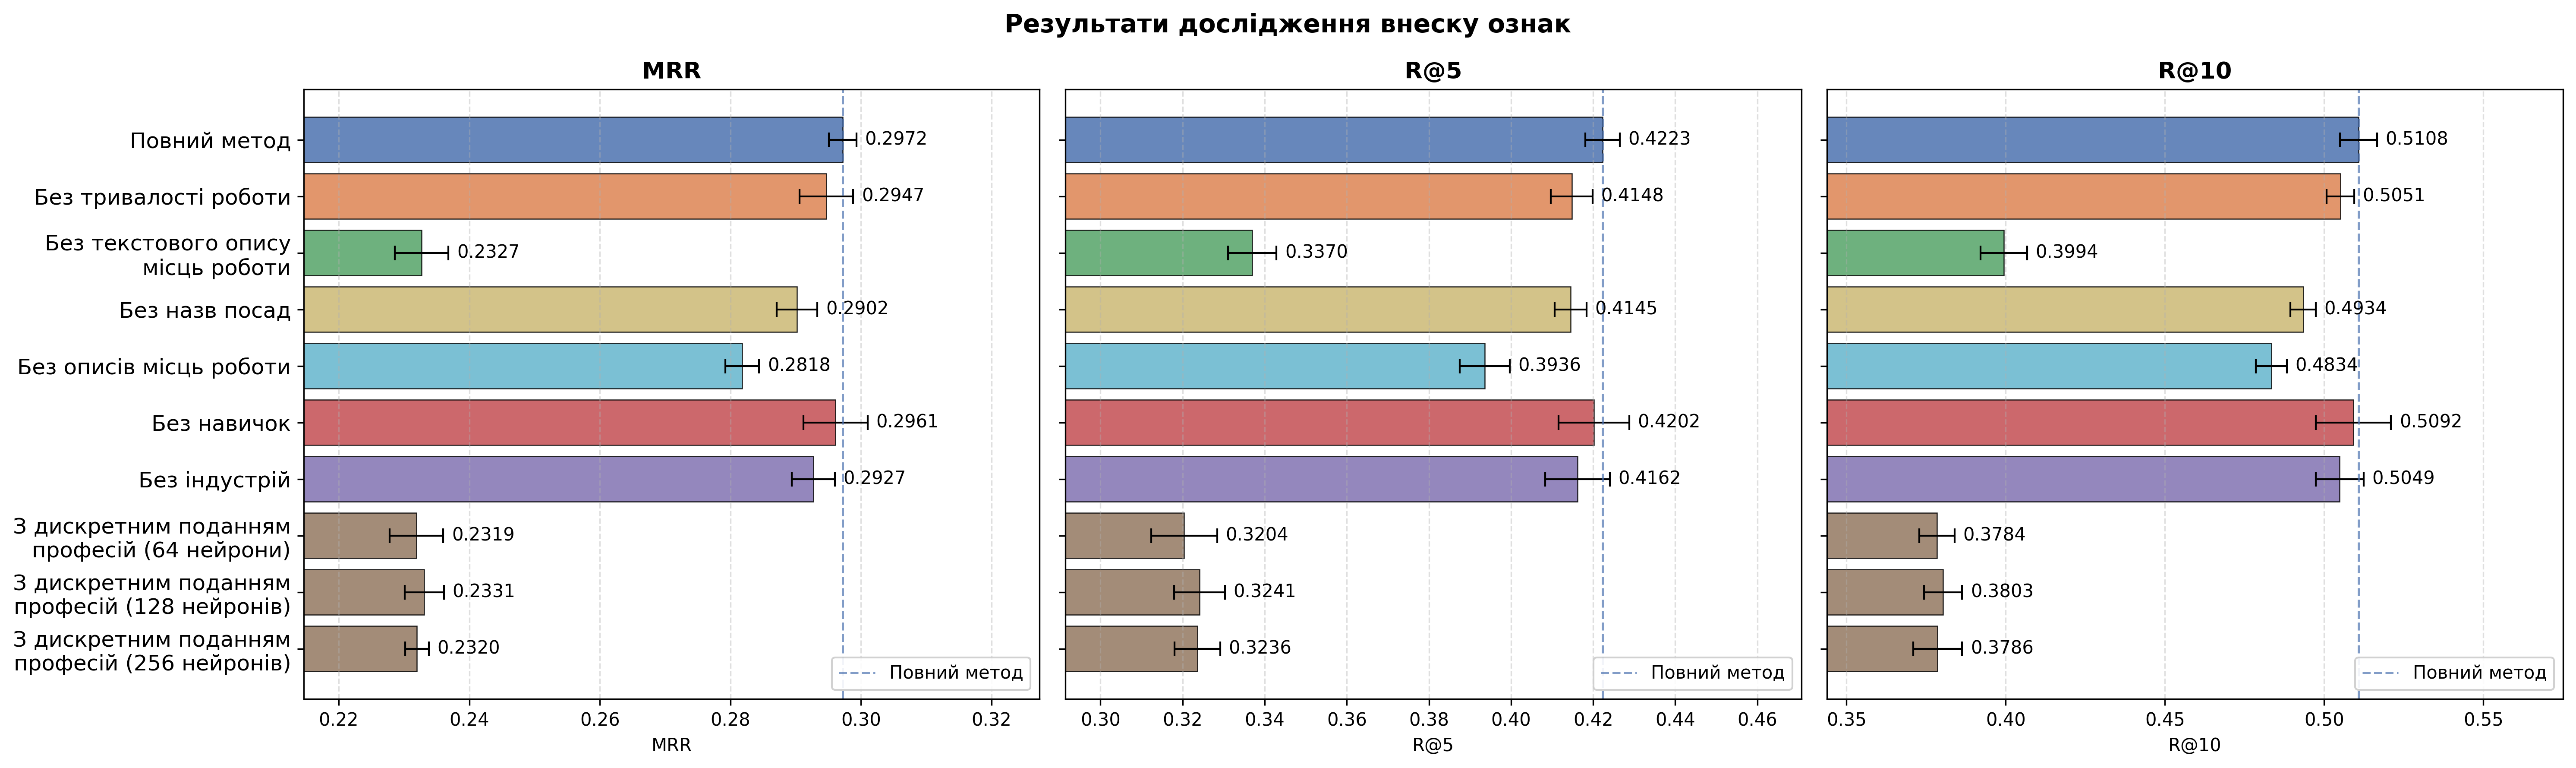

In [2]:
import matplotlib.pyplot as plt
import numpy as np

methods = [
    'Повний метод',
    'Без тривалості роботи',
    'Без текстового опису\nмісць роботи',
    'Без назв посад',
    'Без описів місць роботи',
    'Без навичок',
    'Без індустрій',
    'З дискретним поданням\nпрофесій (64 нейрони)',
    'З дискретним поданням\nпрофесій (128 нейронів)',
    'З дискретним поданням\nпрофесій (256 нейронів)',
]

mrr      = np.array([0.2972, 0.2947, 0.2327, 0.2902, 0.2818, 0.2961, 0.2927, 0.2319, 0.2331, 0.2320])
mrr_std  = np.array([0.0021, 0.0041, 0.0041, 0.0031, 0.0026, 0.0049, 0.0033, 0.0041, 0.0030, 0.0018])

r5       = np.array([0.4223, 0.4148, 0.3370, 0.4145, 0.3936, 0.4202, 0.4162, 0.3204, 0.3241, 0.3236])
r5_std   = np.array([0.0042, 0.0051, 0.0059, 0.0039, 0.0061, 0.0086, 0.0079, 0.0080, 0.0062, 0.0056])

r10      = np.array([0.5108, 0.5051, 0.3994, 0.4934, 0.4834, 0.5092, 0.5049, 0.3784, 0.3803, 0.3786])
r10_std  = np.array([0.0058, 0.0043, 0.0073, 0.0040, 0.0049, 0.0118, 0.0075, 0.0055, 0.0060, 0.0077])

metrics = [
    ('MRR',  mrr, mrr_std),
    ('R@5',  r5,  r5_std),
    ('R@10', r10, r10_std),
]

full_color     = '#4C72B0'
discrete_color = '#937860'
bar_colors = [
    full_color,        # Повний метод
    '#DD8452',         # Без тривалості роботи
    '#55A467',         # Без текстового опису
    '#CCB974',         # Без назв посад
    '#64B5CD',         # Без описів місць роботи
    '#C44E52',         # Без навичок
    '#8172B2',         # Без індустрії
    discrete_color,    # З дискретним поданням (64)
    discrete_color,    # З дискретним поданням (128)
    discrete_color,    # З дискретним поданням (256)
]

y_pos = np.arange(len(methods))

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True, dpi=300)

for ax, (name, vals, errs) in zip(axes, metrics):
    ax.barh(y_pos, vals, xerr=errs, color=bar_colors, alpha=0.85,
            edgecolor='black', linewidth=0.6,
            error_kw={'ecolor': 'black', 'capsize': 4, 'elinewidth': 1.0})

    full_val = vals[0]
    ax.axvline(full_val, color=full_color, linestyle='--',
               linewidth=1.2, alpha=0.7, label='Повний метод')

    for i, (v, e) in enumerate(zip(vals, errs)):
        ax.text(v + e + (vals.max() - vals.min()) * 0.02, i,
                f'{v:.4f}', va='center', fontsize=10)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(methods, fontsize=12)
    ax.invert_yaxis()
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel(name)
    ax.grid(True, axis='x', linestyle='--', alpha=0.4)

    lo = float((vals - errs).min())
    hi = float((vals + errs).max())
    pad = (hi - lo) * 0.18
    ax.set_xlim(lo - pad, hi + pad * 2)

    ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

fig.suptitle('Результати дослідження внеску ознак',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()